In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())

lung cancer


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.path.exists('/root/.kaggle/kaggle.json'))  # should print True if creds still set up

!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images -p /content/LungCancerData --unzip

print(os.listdir('/content/LungCancerData'))

False
Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
100% 119M/119M [00:08<00:00, 15.4MB/s]

['Data']


In [3]:
import os
for root, dirs, files in os.walk('/content/LungCancerData'):
    print(root, dirs[:5])

/content/LungCancerData ['Data']
/content/LungCancerData/Data ['valid', 'train', 'test']
/content/LungCancerData/Data/valid ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
/content/LungCancerData/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa []
/content/LungCancerData/Data/valid/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib []
/content/LungCancerData/Data/valid/normal []
/content/LungCancerData/Data/valid/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa []
/content/LungCancerData/Data/train ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
/content/LungCancerData/Data/train/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa []
/content/LungCancerData/Data/train/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib []
/content/LungCancerData/Data/train/normal []
/content/LungCa

In [4]:
import os

rename_map = {
    'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 'squamous.cell.carcinoma',
    'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 'adenocarcinoma',
    'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 'large.cell.carcinoma',
    'normal': 'normal',  # already matches, harmless to include
}

for split in ['train', 'valid']:
    split_path = f'/content/LungCancerData/Data/{split}'
    for old_name, new_name in rename_map.items():
        old_path = os.path.join(split_path, old_name)
        new_path = os.path.join(split_path, new_name)
        if os.path.exists(old_path) and old_path != new_path:
            os.rename(old_path, new_path)

# verify all three splits now have matching folder names
for split in ['train', 'valid', 'test']:
    print(split, sorted(os.listdir(f'/content/LungCancerData/Data/{split}')))

train ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
valid ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
test ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_set = datasets.ImageFolder(root='/content/LungCancerData/Data/train', transform=train_transform)
val_set   = datasets.ImageFolder(root='/content/LungCancerData/Data/valid', transform=eval_transform)
test_set  = datasets.ImageFolder(root='/content/LungCancerData/Data/test', transform=eval_transform)

class_names = train_set.classes
print("Classes:", class_names)
print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

# sanity check: confirm all three splits agree on the same classes in the same order
assert train_set.classes == val_set.classes == test_set.classes, "Class mismatch between splits!"
print("Class lists match across all splits — safe to proceed.")

Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Train: 613, Val: 72, Test: 315
Class lists match across all splits — safe to proceed.


In [7]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [8]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights='IMAGENET1K_V2')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to('cuda')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


In [12]:
import torch.optim as optim
import torch
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {running_loss/len(train_loader):.4f} — Val Acc: {val_acc:.4f}")

Epoch 1/10 — Loss: 0.9371 — Val Acc: 0.5139
Epoch 2/10 — Loss: 0.8664 — Val Acc: 0.5556
Epoch 3/10 — Loss: 0.8328 — Val Acc: 0.5833
Epoch 4/10 — Loss: 0.7781 — Val Acc: 0.5278
Epoch 5/10 — Loss: 0.7494 — Val Acc: 0.5833
Epoch 6/10 — Loss: 0.7152 — Val Acc: 0.6111
Epoch 7/10 — Loss: 0.7190 — Val Acc: 0.5833
Epoch 8/10 — Loss: 0.6714 — Val Acc: 0.5972
Epoch 9/10 — Loss: 0.6535 — Val Acc: 0.6389
Epoch 10/10 — Loss: 0.6120 — Val Acc: 0.6111


In [13]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs_finetune = 5

for epoch in range(num_epochs_finetune):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Fine-tune Epoch {epoch+1}/{num_epochs_finetune} — Loss: {running_loss/len(train_loader):.4f} — Val Acc: {val_acc:.4f}")

Fine-tune Epoch 1/5 — Loss: 0.5165 — Val Acc: 0.6250
Fine-tune Epoch 2/5 — Loss: 0.3728 — Val Acc: 0.7639
Fine-tune Epoch 3/5 — Loss: 0.1981 — Val Acc: 0.8056
Fine-tune Epoch 4/5 — Loss: 0.1093 — Val Acc: 0.8472
Fine-tune Epoch 5/5 — Loss: 0.0664 — Val Acc: 0.8611


                         precision    recall  f1-score   support

         adenocarcinoma       0.85      0.83      0.84       120
   large.cell.carcinoma       0.87      0.80      0.84        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.83      0.90      0.86        90

               accuracy                           0.87       315
              macro avg       0.89      0.88      0.88       315
           weighted avg       0.87      0.87      0.87       315



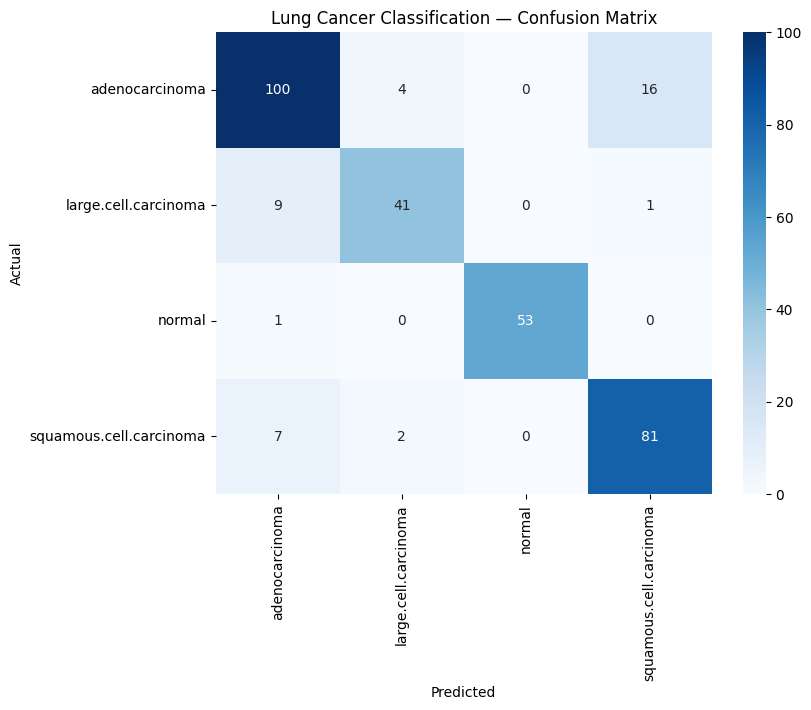

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to('cuda')
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Lung Cancer Classification — Confusion Matrix')
plt.savefig('/content/drive/MyDrive/lung_cancer_confusion_matrix.png')
plt.show()

In [15]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names
}, '/content/drive/MyDrive/lung_cancer_model.pt')

print("Saved to /content/drive/MyDrive/lung_cancer_model.pt")

Saved to /content/drive/MyDrive/lung_cancer_model.pt
